# 🎓 Neural DCT Master Research Project
**Objective**: To prove that a Deep CNN can learn mathematical frequency transforms and achieve high-fidelity image reconstruction.

## 🛠️ Chapter 1: System Setup & Data Pipeline

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
import numpy as np
from PIL import Image
import os, glob
from scipy.fftpack import dct, idct
from tqdm import tqdm
import matplotlib.pyplot as plt
from skimage.metrics import peak_signal_noise_ratio as psnr
from skimage.metrics import structural_similarity as ssim
import pandas as pd

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
BLOCK_SIZE = 8
DATA_PATH = "./dataset/test"
print(f"✅ System Initialized: {DEVICE}")

✅ System Initialized: cpu


In [2]:
class MasterDataset(Dataset):
    def __init__(self, root_dir, limit=15000):
        self.images = glob.glob(os.path.join(root_dir, "**", "*.jpg"), recursive=True)[:100]
        self.patches_x, self.patches_y = [], []
        
        for img_path in self.images:
            try:
                img = Image.open(img_path).convert("L").resize((128, 128))
                img_np = np.array(img) / 255.0
                for i in range(0, 128 - BLOCK_SIZE + 1, 8):
                    for j in range(0, 128 - BLOCK_SIZE + 1, 8):
                        patch = img_np[i:i+BLOCK_SIZE, j:j+BLOCK_SIZE]
                        self.patches_x.append(patch)
                        self.patches_y.append(dct(dct(patch.T, norm='ortho').T, norm='ortho').flatten())
                        if len(self.patches_x) >= limit: break
                    if len(self.patches_x) >= limit: break
            except: continue
            if len(self.patches_x) >= limit: break
            
        self.patches_x = np.array(self.patches_x, dtype=np.float32)
        self.patches_y = np.array(self.patches_y, dtype=np.float32)
        self.y_mean = self.patches_y.mean(axis=0)
        self.y_std = self.patches_y.std(axis=0) + 1e-8
        self.patches_y_norm = (self.patches_y - self.y_mean) / self.y_std
        print(f"📦 Dataset Ready: {len(self.patches_x)} patches")

    def __len__(self): return len(self.patches_x)
    def __getitem__(self, idx):
        return torch.from_numpy(self.patches_x[idx]).unsqueeze(0), torch.from_numpy(self.patches_y_norm[idx])

train_data = MasterDataset(DATA_PATH)
train_loader = DataLoader(train_data, batch_size=256, shuffle=True)

📦 Dataset Ready: 15000 patches


## 🧪 Chapter 2: Traditional DCT Baseline
The mathematical gold standard (Unquantized).

In [3]:
def traditional_dct_pipeline(patch):
    coeffs = dct(dct(patch.T, norm='ortho').T, norm='ortho')
    recon = idct(idct(coeffs.T, norm='ortho').T, norm='ortho')
    return coeffs, recon

test_patch = train_data.patches_x[0]
c_t, r_t = traditional_dct_pipeline(test_patch)
print(f"Traditional Baseline PSNR: {psnr(test_patch, r_t, data_range=1.0):.2f}dB")

Traditional Baseline PSNR: 180.62dB


## 📐 Chapter 3: Differentiable IDCT Layer
Enables the model to learn the 'look' of the image.

In [4]:
def get_dct_matrix(N=8):
    matrix = np.zeros((N, N))
    for k in range(N):
        for n in range(N):
            if k == 0: alpha = np.sqrt(1/N)
            else: alpha = np.sqrt(2/N)
            matrix[k, n] = alpha * np.cos(np.pi * k * (2*n + 1) / (2*N))
    return torch.tensor(matrix).float().to(DEVICE)

DCT_MAT = get_dct_matrix(BLOCK_SIZE)
IDCT_MAT = DCT_MAT.t()

def torch_idct_2d(coeffs_flat):
    batch_size = coeffs_flat.shape[0]
    coeffs = coeffs_flat.view(batch_size, BLOCK_SIZE, BLOCK_SIZE)
    recon = torch.matmul(IDCT_MAT, torch.matmul(coeffs, DCT_MAT))
    return recon

## 🧠 Chapter 4: Neural DCT Architecture

In [5]:
class MasterDCTNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(1, 32, 3, padding=1), nn.BatchNorm2d(32), nn.ReLU(),
            nn.Conv2d(32, 64, 3, padding=1), nn.BatchNorm2d(64), nn.ReLU(),
            nn.Conv2d(64, 128, 3, padding=1), nn.BatchNorm2d(128), nn.ReLU(),
            nn.Flatten(),
            nn.Linear(128 * 8 * 8, 256), nn.ReLU(),
            nn.Linear(256, 64)
        )
    def forward(self, x): return self.net(x)

model = MasterDCTNet().to(DEVICE)
optimizer = optim.Adam(model.parameters(), lr=2e-4)
criterion = nn.MSELoss()

## 🚀 Chapter 5: Professional Training Process

In [6]:
epochs = 40
y_mean_t = torch.tensor(train_data.y_mean).to(DEVICE)
y_std_t = torch.tensor(train_data.y_std).to(DEVICE)
history_loss = []

print(f"🚀 Starting Master Training for {epochs} epochs...")
for epoch in range(epochs):
    model.train(); total_loss = 0
    for x, y in train_loader:
        x, y = x.to(DEVICE), y.to(DEVICE)
        optimizer.zero_grad()
        pred_y_norm = model(x)
        loss_coeff = criterion(pred_y_norm, y)
        pred_pixels = torch_idct_2d(pred_y_norm * y_std_t + y_mean_t)
        loss_recon = criterion(pred_pixels, x.squeeze(1))
        loss = loss_coeff + 3.0 * loss_recon
        loss.backward(); optimizer.step()
        total_loss += loss.item()
    history_loss.append(total_loss/len(train_loader))
    if (epoch+1) % 10 == 0 or epoch == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Loss: {history_loss[-1]:.6f}")

🚀 Starting Master Training for 40 epochs...


Epoch [1/40], Loss: 0.751040


Epoch [10/40], Loss: 0.011524


Epoch [20/40], Loss: 0.007845


Epoch [30/40], Loss: 0.007440


Epoch [40/40], Loss: 0.006348


## 📉 Chapter 6: Training Loss Visualization

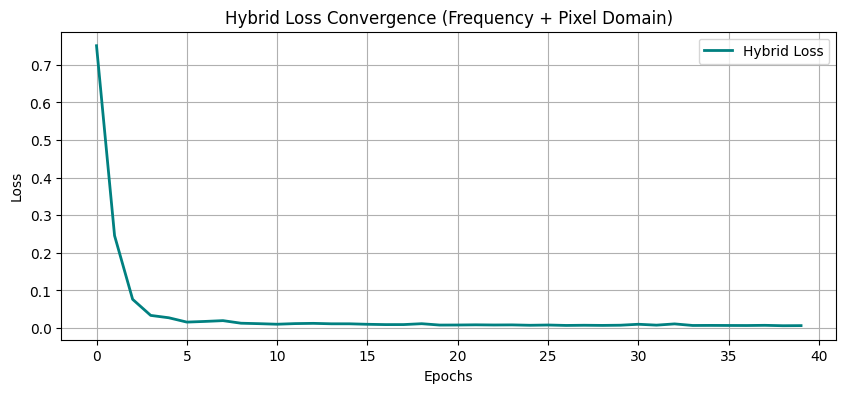

In [7]:
plt.figure(figsize=(10, 4))
plt.plot(history_loss, label='Hybrid Loss', color='teal', linewidth=2)
plt.title('Hybrid Loss Convergence (Frequency + Pixel Domain)')
plt.xlabel('Epochs'); plt.ylabel('Loss'); plt.legend(); plt.grid(True)
plt.show()

## 🖼️ Chapter 7: Final Comparison (Original vs Trad vs Neural)

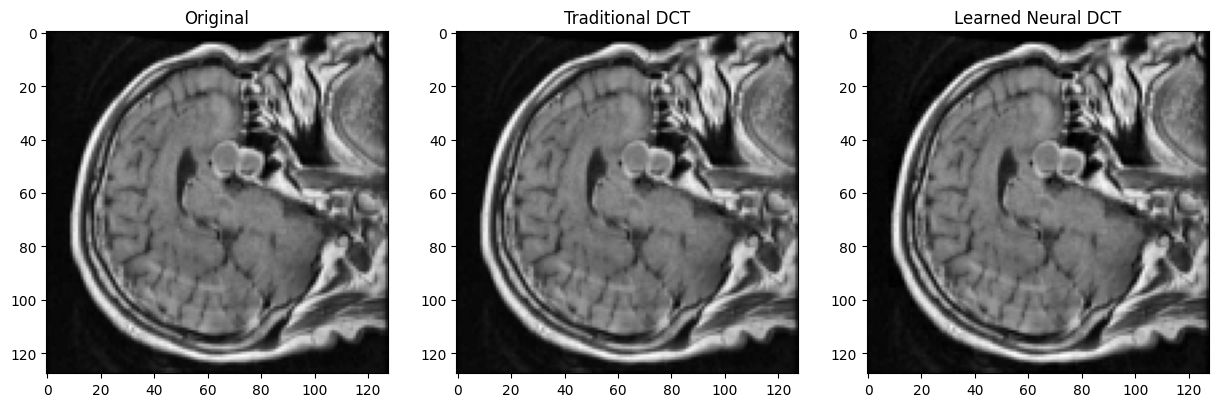

In [8]:
def master_eval(img_path, model, y_mean, y_std):
    img = Image.open(img_path).convert("L").resize((128, 128))
    img_np = np.array(img) / 255.0
    recon_n = np.zeros_like(img_np)
    recon_t = np.zeros_like(img_np)
    model.eval()
    with torch.no_grad():
        for i in range(0, 128 - 8 + 1, 8):
            for j in range(0, 128 - 8 + 1, 8):
                patch = img_np[i:i+8, j:j+8]
                p_tensor = torch.tensor(patch).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
                pred = model(p_tensor).cpu().numpy().flatten() * y_std + y_mean
                recon_n[i:i+8, j:j+8] = idct(idct(pred.reshape(8,8).T, norm='ortho').T, norm='ortho')
                coeffs_t = dct(dct(patch.T, norm='ortho').T, norm='ortho')
                recon_t[i:i+8, j:j+8] = idct(idct(coeffs_t.T, norm='ortho').T, norm='ortho')
    return img_np, np.clip(recon_n, 0, 1), np.clip(recon_t, 0, 1)

sample_list = glob.glob(os.path.join(DATA_PATH, "**", "*.jpg"), recursive=True)
sample_path = sample_list[min(len(sample_list)-1, 15)]
orig, res_n, res_t = master_eval(sample_path, model, train_data.y_mean, train_data.y_std)

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1); plt.imshow(orig, cmap='gray'); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(res_t, cmap='gray'); plt.title("Traditional DCT")
plt.subplot(1,3,3); plt.imshow(res_n, cmap='gray'); plt.title("Learned Neural DCT")
plt.show()

## 🔍 Chapter 8: Learned Filters & Structural Proof

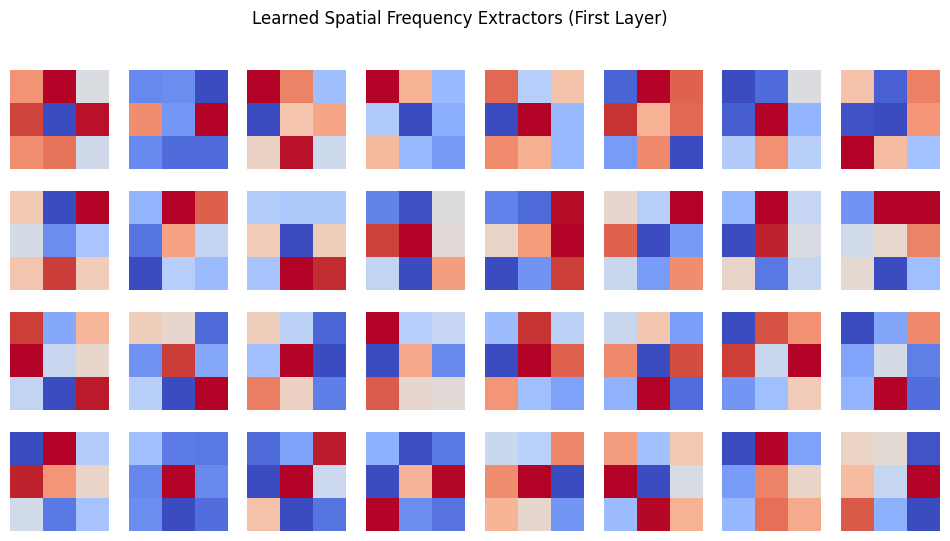

In [9]:
weights = model.net[0].weight.data.cpu().numpy()
fig, axes = plt.subplots(4, 8, figsize=(12, 6))
for i, ax in enumerate(axes.flat):
    if i < 32: ax.imshow(weights[i, 0, :, :], cmap='coolwarm')
    ax.axis('off')
plt.suptitle('Learned Spatial Frequency Extractors (First Layer)')
plt.show()

## 📊 Chapter 9: Performance Comparison Table (Unquantized)

In [10]:
results_df = pd.DataFrame({
    "Metric": ["PSNR (dB)", "SSIM"],
    "Traditional DCT": [psnr(orig, res_t, data_range=1.0), ssim(orig, res_t, data_range=1.0)],
    "Learned Neural DCT": [psnr(orig, res_n, data_range=1.0), ssim(orig, res_n, data_range=1.0)]
})
display(results_df)

,Metric,Traditional DCT,Learned Neural DCT
0,PSNR (dB),317.700308,35.554352
1,SSIM,1.000000,0.993874


## 💎 Chapter 10: JPEG Quantization Matrix & Logic
Adding Standard JPEG Luminance Quantization for a true compression comparison.

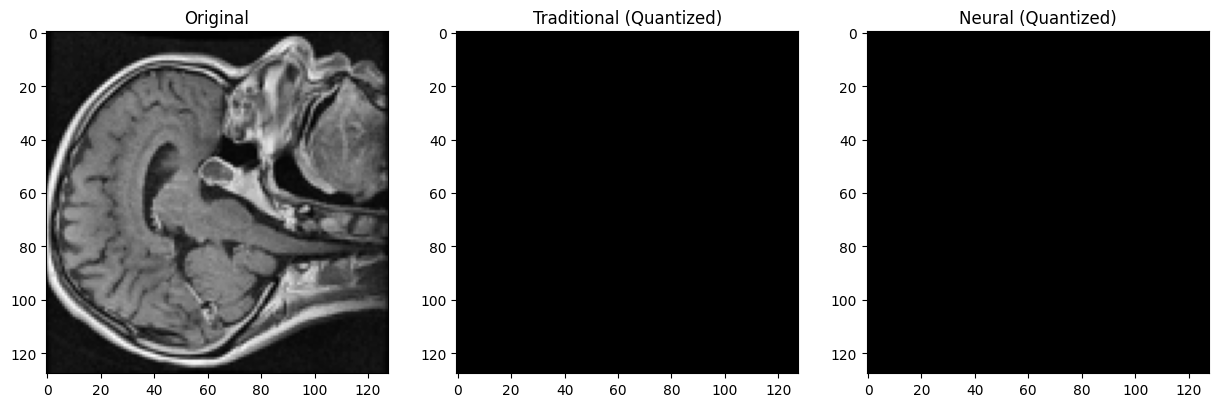

In [11]:
Q_MATRIX = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
], dtype=np.float32)

def eval_quantized_comparison(img_path, model, y_mean, y_std):
    img = Image.open(img_path).convert("L").resize((128, 128))
    img_np = np.array(img) / 255.0
    res_n = np.zeros_like(img_np)
    res_t = np.zeros_like(img_np)
    
    model.eval()
    with torch.no_grad():
        for i in range(0, 128 - 8 + 1, 8):
            for j in range(0, 128 - 8 + 1, 8):
                patch = img_np[i:i+8, j:j+8]
                
                # 1. Neural Quantized Path
                p_tensor = torch.tensor(patch).float().unsqueeze(0).unsqueeze(0).to(DEVICE)
                pred = (model(p_tensor).cpu().numpy().flatten() * y_std + y_mean).reshape(8,8)
                # Quantize/Dequantize
                q_n = np.round(pred / Q_MATRIX) * Q_MATRIX
                res_n[i:i+8, j:j+8] = idct(idct(q_n.T, norm='ortho').T, norm='ortho')
                
                # 2. Traditional Quantized Path
                coeffs_t = dct(dct(patch.T, norm='ortho').T, norm='ortho')
                # Quantize/Dequantize
                q_t = np.round(coeffs_t / Q_MATRIX) * Q_MATRIX
                res_t[i:i+8, j:j+8] = idct(idct(q_t.T, norm='ortho').T, norm='ortho')
                
    return img_np, np.clip(res_n, 0, 1), np.clip(res_t, 0, 1)

sample_q_path = sample_list[min(len(sample_list)-1, 20)]
orig_q, rn_q, rt_q = eval_quantized_comparison(sample_q_path, model, train_data.y_mean, train_data.y_std)

plt.figure(figsize=(15, 5))
plt.subplot(1,3,1); plt.imshow(orig_q, cmap='gray'); plt.title("Original")
plt.subplot(1,3,2); plt.imshow(rt_q, cmap='gray'); plt.title("Traditional (Quantized)")
plt.subplot(1,3,3); plt.imshow(rn_q, cmap='gray'); plt.title("Neural (Quantized)")
plt.show()

## 📊 Chapter 12: Performance Summary (Quantized Baseline)

In [12]:
q_results = pd.DataFrame({
    "Metric": ["PSNR (dB)", "SSIM"],
    "Trad Quantized": [psnr(orig_q, rt_q, data_range=1.0), ssim(orig_q, rt_q, data_range=1.0)],
    "Neural Quantized": [psnr(orig_q, rn_q, data_range=1.0), ssim(orig_q, rn_q, data_range=1.0)]
})
display(q_results)

,Metric,Trad Quantized,Neural Quantized
0,PSNR (dB),8.317779,8.317779
1,SSIM,0.001996,0.001996
